# Ex.3 Market Risk Case

### 0. Libraries

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from scipy.stats import norm
from scipy.stats import binom
from scipy.stats import chi2
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import Rectangle
from datetime import datetime

### 1. Data ingestion

In [2]:
# Load data
PROJECT=Path(".")
DATA=PROJECT/"data"
OUTPUT=PROJECT/"output"

def load_data(data_path):

    return{
        'counterparties':pd.read_excel(data_path/'Counterparties.xlsx'),
        'daily_pnl':pd.read_excel(data_path/'Daily_PnL.xlsx'),
        'fx_rates':pd.read_excel(data_path/'FX_Rates.xlsx'),
        'historical_prices':pd.read_excel(data_path/'Historical_Prices.xlsx'),
        'instruments':pd.read_excel(data_path/'Instruments.xlsx'),
        'limits':pd.read_excel(data_path/'Limits.xlsx'),
        'market_prices':pd.read_excel(data_path/'Market_Prices.xlsx'),
        'positions':pd.read_excel(data_path/'Positions.xlsx'),
        'risk_factors':pd.read_excel(data_path/'Risk_factors.xlsx'),
        'traders':pd.read_excel(data_path/'Traders.xlsx')
    }

In [3]:
data = load_data(DATA)

counterparties = data["counterparties"]
daily_pnl=data["daily_pnl"]
fx_rates = data["fx_rates"]
historical_prices = data["historical_prices"]
instruments=data["instruments"]
limits = data["limits"]
market_prices=data["market_prices"]
positions = data["positions"]
risk_factors = data["risk_factors"]
traders= data["traders"]

### 2. Data Quality Assessment

In [4]:
def inspect_data(df):
   
    summary = pd.DataFrame({
        'Data type': df.dtypes,
        'Total NaN values': df.isnull().sum(),
        'NaN %': (df.isnull().sum() / len(df) * 100).round(2)
    })

    print(f"Matrix dimension: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"Nº of duplicates: {df.duplicated().sum()}")

    duplicate_rows = df[df.duplicated()]

    return summary, duplicate_rows

In [5]:
# Inspect counterparties df
inspect_data(counterparties)
# All IDs are unique
print('Nº of unique values:',len(counterparties['CounterpartyID'].unique()))

Matrix dimension: (200, 4)
Columns: ['CounterpartyID', 'Name', 'Country', 'InternalRating']
Nº of duplicates: 0
Nº of unique values: 200


In [6]:
# Inspect daily_pnl
inspect_data(daily_pnl)
# TradeID is not unique
print('Nº of unique values:',len(daily_pnl['TradeID'].unique()))

Matrix dimension: (5000, 2)
Columns: ['TradeID', 'PnL']
Nº of duplicates: 0
Nº of unique values: 3125


In [7]:
# Inspect fx_rates
inspect_data(fx_rates)

Matrix dimension: (4, 2)
Columns: ['Currency', 'USD_Rate']
Nº of duplicates: 0


(         Data type  Total NaN values  NaN %
 Currency    object                 0    0.0
 USD_Rate   float64                 0    0.0,
 Empty DataFrame
 Columns: [Currency, USD_Rate]
 Index: [])

In [8]:
# Inspect historical_prices
inspect_data(historical_prices)
# The InstrumentID is unique
print('Nº of unique values:',len(historical_prices['InstrumentID'].unique()))
print(len(historical_prices[historical_prices['Date']=='2025-08-01']['InstrumentID']))

Matrix dimension: (150000, 3)
Columns: ['Date', 'InstrumentID', 'Price']
Nº of duplicates: 0
Nº of unique values: 600
600


In [9]:
# Inspect instruments
inspect_data(instruments)
# The instrumentID is unique
print('Nº of unique values:',len(instruments['InstrumentID'].unique()))

Matrix dimension: (600, 5)
Columns: ['InstrumentID', 'Type', 'Issuer', 'Maturity', 'Rating']
Nº of duplicates: 0
Nº of unique values: 600


In [10]:
# Inspect limits
inspect_data(limits)

Matrix dimension: (3, 3)
Columns: ['Desk', 'VaR_Limit', 'Position_Limit']
Nº of duplicates: 0


(               Data type  Total NaN values  NaN %
 Desk              object                 0    0.0
 VaR_Limit          int64                 0    0.0
 Position_Limit     int64                 0    0.0,
 Empty DataFrame
 Columns: [Desk, VaR_Limit, Position_Limit]
 Index: [])

In [11]:
# Market prices
inspect_data(market_prices)
# The InstrumentID is unique
print(len(market_prices[market_prices['Date']=='2026-08-01']['InstrumentID']))

Matrix dimension: (600, 3)
Columns: ['InstrumentID', 'Date', 'Price']
Nº of duplicates: 0
600


In [12]:
# Inspect positions
inspect_data(positions)

Matrix dimension: (5000, 7)
Columns: ['TradeID', 'Book', 'TraderID', 'InstrumentID', 'CounterpartyID', 'Quantity', 'Currency']
Nº of duplicates: 0


(               Data type  Total NaN values  NaN %
 TradeID           object                 0   0.00
 Book              object                 0   0.00
 TraderID          object                16   0.32
 InstrumentID      object                 0   0.00
 CounterpartyID    object                 0   0.00
 Quantity           int64                 0   0.00
 Currency          object               962  19.24,
 Empty DataFrame
 Columns: [TradeID, Book, TraderID, InstrumentID, CounterpartyID, Quantity, Currency]
 Index: [])

In [13]:
# Inspect risk factors
inspect_data(risk_factors)

Matrix dimension: (800, 2)
Columns: ['InstrumentID', 'RiskFactor']
Nº of duplicates: 124


(             Data type  Total NaN values  NaN %
 InstrumentID    object                 0    0.0
 RiskFactor      object                 0    0.0,
     InstrumentID RiskFactor
 48        INS437        VIX
 80        INS080     EURUSD
 86        INS258      US10Y
 104       INS356        VIX
 111       INS079      US10Y
 ..           ...        ...
 777       INS184        VIX
 779       INS272      SP500
 780       INS079      US10Y
 784       INS419      US10Y
 787       INS473      SP500
 
 [124 rows x 2 columns])

In [14]:
# Inspect traders
inspect_data(traders)

Matrix dimension: (50, 3)
Columns: ['TraderID', 'TraderName', 'Desk']
Nº of duplicates: 0


(           Data type  Total NaN values  NaN %
 TraderID      object                 0    0.0
 TraderName    object                 0    0.0
 Desk          object                 8   16.0,
 Empty DataFrame
 Columns: [TraderID, TraderName, Desk]
 Index: [])

In [15]:
# Summary table of all issues I found.

summary_table = {
    "Field": ['InternalRating','Maturity','Rating','TraderID','Currency','RiskFactor','Desk'],
    "NaN": [counterparties['InternalRating'].isnull().sum(),instruments['Maturity'].isnull().sum(),
            instruments['Rating'].isnull().sum(),positions['TraderID'].isnull().sum(), 
            positions['Currency'].isnull().sum(),0,traders['Desk'].isnull().sum()],
    "Duplicates":[0,0,0,0,0,risk_factors.duplicated().sum(),0]
}

index=pd.MultiIndex.from_tuples([("Counterparties",""),
                                 ("Instruments",""), 
                                 ("Instruments",""),
                                 ('Positions',""),
                                 ('Positions',""),
                                 ('Risk Factors',""),
                                 ('Traders',"")])

summary_table_df = pd.DataFrame(summary_table, index = index)
summary_table_df

Field  NaN  Duplicates
Counterparties   InternalRating   60           0
Instruments            Maturity  307           0
                         Rating  117           0
Positions              TraderID   16           0
                       Currency  962           0
Risk Factors         RiskFactor    0         124
Traders                    Desk    8           0

### 3. Data Cleaning

#### 3.1 Missing values (Nan)

I would ask front office for them, or let my manager know. And find a solution about to approach or solve it.

#### 3.2 Duplicates

In [16]:
# I would remove duplicates
risk_factors=risk_factors.drop_duplicates()

#### 3.3 Date format

In [17]:
# I would standarize date format
market_prices['Date']=pd.to_datetime(market_prices['Date'],format='mixed')
instruments['Maturity']=pd.to_datetime(instruments['Maturity'],format='mixed')
historical_prices['Date']=pd.to_datetime(historical_prices['Date'],format='mixed')

In [18]:
instruments['Maturity'].unique()

<DatetimeArray>
['2033-08-23 00:00:00',                 'NaT', '2030-01-15 00:00:00',
 '2030-03-10 00:00:00', '2030-09-13 00:00:00', '2030-07-14 00:00:00',
 '2032-05-18 00:00:00', '2031-12-05 00:00:00', '2033-05-26 00:00:00',
 '2032-03-30 00:00:00',
 ...
 '2031-08-06 00:00:00', '2032-03-19 00:00:00', '2030-05-15 00:00:00',
 '2032-07-28 00:00:00', '2030-05-31 00:00:00', '2033-11-14 00:00:00',
 '2033-02-12 00:00:00', '2031-04-19 00:00:00', '2030-02-14 00:00:00',
 '2033-04-08 00:00:00']
Length: 268, dtype: datetime64[ns]

In [19]:
fx_rates['Currency'].unique()

array(['USD', 'EUR', 'SEK', 'GBP'], dtype=object)

In [20]:
positions['Currency'].unique()

array(['USD', 'SEK', nan, 'EUR', 'GBP'], dtype=object)

### 4. Build the Master Portfolio

In [21]:
def build_master_portfolio(positions,daily_pnl,market_prices,instruments,counterparties,traders,fx_rates,risk_factors,limits):
    df=(
        positions.merge(daily_pnl,how='left',on='TradeID')
        .merge(market_prices,how='left',on='InstrumentID')
        .merge(instruments,how='left',on='InstrumentID')
        .merge(counterparties,how='left',on='CounterpartyID')
        .merge(traders,how='left',on='TraderID')
        .merge(fx_rates,how='left',on='Currency')
        .merge(risk_factors,how='left',on='InstrumentID')
        .merge(limits,how='left',on='Desk'))

    return df

df_master=build_master_portfolio(positions,daily_pnl,market_prices,instruments,counterparties,traders,fx_rates,risk_factors,limits)
df_master

,TradeID,Book,TraderID,InstrumentID,CounterpartyID,Quantity,Currency,PnL,Date,Price,...,Rating,Name,Country,InternalRating,TraderName,Desk,USD_Rate,RiskFactor,VaR_Limit,Position_Limit
0,T1001,EQ01,NaN,INS394,CP40,-422,USD,-4736.0,2026-08-01,104.75,...,AAA,Goldman,Sweden,A,NaN,NaN,1.00,SP500,NaN,NaN
1,T1001,EQ01,NaN,INS394,CP40,-422,USD,-4736.0,2026-08-01,104.75,...,AAA,Goldman,Sweden,A,NaN,NaN,1.00,US10Y,NaN,NaN
2,T1001,FX01,TR38,INS098,CP37,1854,USD,-4736.0,2026-08-01,83.00,...,A,Nordea,Sweden,NaN,Anna,Rates,1.00,SP500,900000.0,35000000.0
3,T1001,FX01,TR38,INS098,CP37,1854,USD,-4736.0,2026-08-01,83.00,...,A,Nordea,Sweden,NaN,Anna,Rates,1.00,VIX,900000.0,35000000.0
4,T1001,FX01,TR38,INS098,CP37,1854,USD,-4736.0,2026-08-01,83.00,...,A,Nordea,Sweden,NaN,Anna,Rates,1.00,US10Y,900000.0,35000000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9675,T5997,FI01,TR41,INS069,CP154,1381,GBP,-2875.0,2026-08-01,238.57,...,BBB,Nordea,Germany,AA,Sam,Equities,1.35,SP500,500000.0,15000000.0
9676,T5997,FI01,TR41,INS069,CP154,1381,GBP,2705.0,2026-08-01,238.57,...,BBB,Nordea,Germany,AA,Sam,Equities,1.35,VIX,500000.0,15000000.0
9677,T5997,FI01,TR41,INS069,CP154,1381,GBP,2705.0,2026-08-01,238.57,...,BBB,Nordea,Germany,AA,Sam,Equities,1.35,SP500,500000.0,15000000.0
9678,T5998,FX01,TR16,INS053,CP106,4380,NaN,-2103.0,2026-08-01,231.08,...,BBB,DB,Sweden,A,Maria,FX,NaN,US10Y,700000.0,25000000.0


### 5. Risk Calculations

In [22]:
def risk_calculations(df):
    
    df = df.copy()
    
    df['MarketValue']=df['Price']*df['Quantity']
    df['MarketValueUSD']=df['MarketValue']*df['USD_Rate']
    df['position']=np.where(df['Quantity']>0,'LONG','SHORT')
    df['abs_MarketValueUSD']=abs(df['MarketValueUSD'])
    
    return df    

df_master=risk_calculations(df_master)
df_master

,TradeID,Book,TraderID,InstrumentID,CounterpartyID,Quantity,Currency,PnL,Date,Price,...,TraderName,Desk,USD_Rate,RiskFactor,VaR_Limit,Position_Limit,MarketValue,MarketValueUSD,position,abs_MarketValueUSD
0,T1001,EQ01,NaN,INS394,CP40,-422,USD,-4736.0,2026-08-01,104.75,...,NaN,NaN,1.00,SP500,NaN,NaN,-44204.50,-44204.5000,SHORT,44204.5000
1,T1001,EQ01,NaN,INS394,CP40,-422,USD,-4736.0,2026-08-01,104.75,...,NaN,NaN,1.00,US10Y,NaN,NaN,-44204.50,-44204.5000,SHORT,44204.5000
2,T1001,FX01,TR38,INS098,CP37,1854,USD,-4736.0,2026-08-01,83.00,...,Anna,Rates,1.00,SP500,900000.0,35000000.0,153882.00,153882.0000,LONG,153882.0000
3,T1001,FX01,TR38,INS098,CP37,1854,USD,-4736.0,2026-08-01,83.00,...,Anna,Rates,1.00,VIX,900000.0,35000000.0,153882.00,153882.0000,LONG,153882.0000
4,T1001,FX01,TR38,INS098,CP37,1854,USD,-4736.0,2026-08-01,83.00,...,Anna,Rates,1.00,US10Y,900000.0,35000000.0,153882.00,153882.0000,LONG,153882.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9675,T5997,FI01,TR41,INS069,CP154,1381,GBP,-2875.0,2026-08-01,238.57,...,Sam,Equities,1.35,SP500,500000.0,15000000.0,329465.17,444777.9795,LONG,444777.9795
9676,T5997,FI01,TR41,INS069,CP154,1381,GBP,2705.0,2026-08-01,238.57,...,Sam,Equities,1.35,VIX,500000.0,15000000.0,329465.17,444777.9795,LONG,444777.9795
9677,T5997,FI01,TR41,INS069,CP154,1381,GBP,2705.0,2026-08-01,238.57,...,Sam,Equities,1.35,SP500,500000.0,15000000.0,329465.17,444777.9795,LONG,444777.9795
9678,T5998,FX01,TR16,INS053,CP106,4380,NaN,-2103.0,2026-08-01,231.08,...,Maria,FX,NaN,US10Y,700000.0,25000000.0,1012130.40,NaN,LONG,NaN


In [23]:
def generate_report(df):
    
    long_exposure=df[df['position']=='LONG']['MarketValueUSD'].sum()
    print('Long exposure (USD)',long_exposure)
    
    short_exposure=df[df['position']=='SHORT']['MarketValueUSD'].sum()
    print('Short exposure (USD)',short_exposure)

    net_exposure=long_exposure+short_exposure
    print('Net exposure (USD)',net_exposure)

    gross_exposure=abs(long_exposure)+abs(short_exposure)
    print('Gross exposure (USD)',gross_exposure)

    print('Desk gross exposure (USD)',df.groupby('Desk')['abs_MarketValueUSD'].sum())
    print('Issuer gross exposure (USD)',df.groupby('Issuer')['abs_MarketValueUSD'].sum())
    print('Country gross exposure (USD)',df.groupby('Country')['abs_MarketValueUSD'].sum())
    print('Rating gross exposure (USD)',df.groupby('Rating')['abs_MarketValueUSD'].sum())
    print('Counterparty gross exposure (USD)',df.groupby('CounterpartyID')['abs_MarketValueUSD'].sum())


### 6. VaR

In [24]:
# Sort values
historical_prices = historical_prices.sort_values(
    ["InstrumentID", "Date"]
)
historical_prices

,Date,InstrumentID,Price
0,2025-08-01,INS001,244.75
600,2025-08-02,INS001,124.24
1200,2025-08-03,INS001,194.01
1800,2025-08-04,INS001,75.19
2400,2025-08-05,INS001,63.68
...,...,...,...
147599,2026-04-03,INS600,243.75
148199,2026-04-04,INS600,132.19
148799,2026-04-05,INS600,180.87
149399,2026-04-06,INS600,81.22


In [25]:
historical_prices["Returns"] = (
    historical_prices
    .groupby("InstrumentID")["Price"]
    .transform(lambda x: np.log(x / x.shift(1)))
)
historical_prices=historical_prices.dropna()
historical_prices

,Date,InstrumentID,Price,Returns
600,2025-08-02,INS001,124.24,-0.678022
1200,2025-08-03,INS001,194.01,0.445695
1800,2025-08-04,INS001,75.19,-0.947891
2400,2025-08-05,INS001,63.68,-0.166148
3000,2025-08-06,INS001,206.88,1.178268
...,...,...,...,...
147599,2026-04-03,INS600,243.75,0.273843
148199,2026-04-04,INS600,132.19,-0.611903
148799,2026-04-05,INS600,180.87,0.313538
149399,2026-04-06,INS600,81.22,-0.800617


In [26]:
# Get MarketValueUSD from the master data 
instrument_market_value=df_master.groupby('InstrumentID')['MarketValueUSD'].sum().reset_index()
instrument_market_value

,InstrumentID,MarketValueUSD
0,INS001,1.176814e+06
1,INS002,-2.942422e+06
2,INS003,-2.745865e+06
3,INS004,-6.151712e+05
4,INS005,-1.642045e+06
...,...,...
595,INS596,-1.094135e+06
596,INS597,-4.323486e+04
597,INS598,-1.840921e+06
598,INS599,-6.508537e+05


In [27]:
instrument_market_value["Weight"] =instrument_market_value["MarketValueUSD"]/ instrument_market_value["MarketValueUSD"].sum()

In [28]:
df_merged_hist_price=df_merged_hist_price = historical_prices.merge(instrument_market_value[["InstrumentID", "Weight",'MarketValueUSD']],on="InstrumentID",how="left")

df_merged_hist_price=df_merged_hist_price.dropna()
df_merged_hist_price

,Date,InstrumentID,Price,Returns,Weight,MarketValueUSD
0,2025-08-02,INS001,124.24,-0.678022,0.021128,1.176814e+06
1,2025-08-03,INS001,194.01,0.445695,0.021128,1.176814e+06
2,2025-08-04,INS001,75.19,-0.947891,0.021128,1.176814e+06
3,2025-08-05,INS001,63.68,-0.166148,0.021128,1.176814e+06
4,2025-08-06,INS001,206.88,1.178268,0.021128,1.176814e+06
...,...,...,...,...,...,...
149395,2026-04-03,INS600,243.75,0.273843,-0.015509,-8.638454e+05
149396,2026-04-04,INS600,132.19,-0.611903,-0.015509,-8.638454e+05
149397,2026-04-05,INS600,180.87,0.313538,-0.015509,-8.638454e+05
149398,2026-04-06,INS600,81.22,-0.800617,-0.015509,-8.638454e+05


In [29]:
df_merged_hist_price["WeightedReturn"] = df_merged_hist_price["Returns"]* df_merged_hist_price["Weight"]
df_merged_hist_price

,Date,InstrumentID,Price,Returns,Weight,MarketValueUSD,WeightedReturn
0,2025-08-02,INS001,124.24,-0.678022,0.021128,1.176814e+06,-0.014325
1,2025-08-03,INS001,194.01,0.445695,0.021128,1.176814e+06,0.009417
2,2025-08-04,INS001,75.19,-0.947891,0.021128,1.176814e+06,-0.020027
3,2025-08-05,INS001,63.68,-0.166148,0.021128,1.176814e+06,-0.003510
4,2025-08-06,INS001,206.88,1.178268,0.021128,1.176814e+06,0.024894
...,...,...,...,...,...,...,...
149395,2026-04-03,INS600,243.75,0.273843,-0.015509,-8.638454e+05,-0.004247
149396,2026-04-04,INS600,132.19,-0.611903,-0.015509,-8.638454e+05,0.009490
149397,2026-04-05,INS600,180.87,0.313538,-0.015509,-8.638454e+05,-0.004863
149398,2026-04-06,INS600,81.22,-0.800617,-0.015509,-8.638454e+05,0.012417


In [30]:
# Returns for each asset (600 assets)
returns_matrix=df_merged_hist_price.pivot(index='Date',columns='InstrumentID',values='Returns')
returns_matrix

InstrumentID,INS001,INS002,INS003,INS004,INS005,INS006,INS007,INS008,INS009,INS010,...,INS591,INS592,INS593,INS594,INS595,INS596,INS597,INS598,INS599,INS600
Date,,,,,,,,,,,,,,,,,,,,,
2025-08-02,-0.678022,-0.980531,-0.234109,0.461565,-0.961314,1.024535,-0.962037,-0.122683,0.014159,1.091240,...,0.052182,0.919789,1.105684,0.116597,0.395483,-0.341306,0.212086,0.270768,0.234388,-1.125187
2025-08-03,0.445695,0.408971,-0.730572,-0.509951,1.050525,-1.356322,0.928516,0.272132,0.484996,-0.049295,...,0.969652,0.178692,-0.534225,0.077030,-0.511273,-0.293466,0.386862,-0.005760,-0.315444,1.125369
2025-08-04,-0.947891,0.990799,0.952108,0.402547,0.231248,1.029781,-0.166875,0.927955,-0.720341,-0.216886,...,-0.476005,0.105787,-0.745201,-0.157896,-0.162173,0.024352,0.059931,0.291473,0.176875,-1.263022
2025-08-05,-0.166148,-0.139059,-0.264960,-0.329251,-1.295472,-0.426093,0.181545,-0.103841,1.013180,0.469979,...,-0.320526,0.226551,0.914310,0.359290,0.220358,0.181999,-0.214100,-0.369102,-0.131295,0.462921
2025-08-06,1.178268,-0.524002,-0.632638,-0.392780,0.400653,0.636231,0.233062,-0.504698,-0.825869,-1.210834,...,0.811292,-0.003821,-0.352385,-0.708834,0.097804,0.187626,0.266014,-0.755748,0.081202,0.438437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-03,-0.161561,-0.562159,-0.562144,1.020343,-0.006978,0.098030,-0.050355,-0.258267,0.633124,0.509767,...,-0.105207,0.079552,0.171826,0.334128,-1.258524,-0.775290,1.376983,-0.567959,-0.835878,0.273843
2026-04-04,-0.753602,0.807194,-0.701324,-0.371178,-0.465932,-0.224956,-0.426438,1.288645,0.056588,-0.382396,...,-0.824365,0.002227,0.068892,0.389737,1.166355,1.207719,-0.543273,-0.099862,0.839993,-0.611903
2026-04-05,0.341388,-0.671820,0.027469,-0.291970,-0.144225,-0.289746,0.924663,-1.184797,-0.211073,-0.562649,...,0.261818,-0.156489,-0.512240,-0.593202,-1.292839,-0.402138,-0.120720,-0.507536,-1.012579,0.313538


In [31]:
# Weights
weights=instrument_market_value.set_index('InstrumentID')['Weight']
weights

InstrumentID
INS001    0.021128
INS002   -0.052827
INS003   -0.049298
INS004   -0.011044
INS005   -0.029480
            ...   
INS596   -0.019644
INS597   -0.000776
INS598   -0.033051
INS599   -0.011685
INS600   -0.015509
Name: Weight, Length: 600, dtype: float64

In [32]:
# Make sure that we take the same instruments in both returns and weights
common_instruments=returns_matrix.columns.intersection(weights.index)
returns_matrix=returns_matrix[common_instruments]
weights=weights[common_instruments]

In [33]:
portfolio_value=instrument_market_value["MarketValueUSD"].sum()
portfolio_value

55699597.090879984

In [34]:
# Parametric VaR
def PVaR(portfolio_value,returns_matrix,weights,conf_level):

    
    mean_returns=returns_matrix.mean()
    cov_matrix=returns_matrix.cov()
    portfolio_mean=np.dot(weights.values,mean_returns.values)
    port_volat=np.sqrt(weights.T@cov_matrix@weights)
    z_score=abs(norm.ppf(1-conf_level))
    PVaR=portfolio_value*(z_score*port_volat-portfolio_mean)# Just to make it positive

    return PVaR


pvar_95=PVaR(portfolio_value,returns_matrix,weights,0.95)
pvar_99=PVaR(portfolio_value,returns_matrix,weights,0.99)

print('PVaR95:','$',pvar_95)
print('PVaR99:','$',pvar_99)

PVaR95: $ 61194430.73019997
PVaR99: $ 86613276.8774745


In [35]:
# Historical VaR
def HVaR(portfolio_value,returns_matrix,weights,percentile):
    
    weights=weights.values
    port_returns=pd.Series(np.dot(returns_matrix.values,weights),index=returns_matrix.index)
    HVaR=np.percentile(port_returns,percentile)*portfolio_value

    return abs(HVaR)

hvar_95=HVaR(portfolio_value,returns_matrix,weights,5)
hvar_99=HVaR(portfolio_value,returns_matrix,weights,1)

print('HVaR95:','$',hvar_95)
print('HVaR99:','$',hvar_99)
print('Largest historical loss:','$',HVaR(portfolio_value,returns_matrix,weights,0))

HVaR95: $ 63714994.35871436
HVaR99: $ 93689389.79380262
Largest historical loss: $ 103740093.00118004


In [36]:
# Expected Shortfall
def Expected_Shortfall(portfolio_value, returns_matrix, weights,percentile):

    port_returns = pd.Series(np.dot(returns_matrix, weights), index=returns_matrix.index)
    port_pnl = port_returns * portfolio_value

    var = HVaR(portfolio_value, returns_matrix,weights, percentile)
    tail_loss = port_pnl[port_pnl <= var]
    es=tail_loss.mean()

    return abs(es)

es_95=Expected_Shortfall(portfolio_value,returns_matrix,weights,5)
es_99=Expected_Shortfall(portfolio_value,returns_matrix,weights,1)   

print('ES95:','$',es_95)
print('ES99:','$',es_99)

ES95: $ 3428050.201062536
ES99: $ 284382.2688944132


### 7. Limit Monitoring

In [37]:
# Exposure(gross and net) by desk
desk_exposure=df_master.groupby('Desk')['MarketValueUSD'].agg(NetExposure='sum',GrossExposure=lambda x: x.abs().sum()).reset_index()
desk_exposure

,Desk,NetExposure,GrossExposure
0,Equities,1.269102e+07,6.432844e+08
1,FX,4.205599e+07,8.831782e+08
2,Rates,-2.793726e+07,6.640063e+08


In [38]:
# Merge exposures with limits
desk_limits=desk_exposure.merge(limits,how='left',on='Desk')

In [39]:
# Position limit utilization
desk_limits['Position_Utilization']=desk_limits['GrossExposure']/desk_limits['Position_Limit']

In [40]:
# Postion breach
desk_limits["Position_Breach"] = np.where(desk_limits["GrossExposure"]> desk_limits["Position_Limit"],'YES','NO')

In [41]:
desk_limits

,Desk,NetExposure,GrossExposure,VaR_Limit,Position_Limit,Position_Utilization,Position_Breach
0,Equities,1.269102e+07,6.432844e+08,500000,15000000,42.885625,YES
1,FX,4.205599e+07,8.831782e+08,700000,25000000,35.327129,YES
2,Rates,-2.793726e+07,6.640063e+08,900000,35000000,18.971610,YES


In [42]:
hist_desk =df_merged_hist_price.merge(df_master[['Desk','InstrumentID']].drop_duplicates(),how='left',on='InstrumentID')

In [43]:
# Hypothetical P&L
hist_desk["HistoricalPnL"] =hist_desk["Returns"]* hist_desk["MarketValueUSD"]

In [44]:
# Aggregate by date and desk
desk_pnl=hist_desk.groupby(['Date','Desk'])['HistoricalPnL'].sum().reset_index()
desk_pnl

,Date,Desk,HistoricalPnL
0,2025-08-02,Equities,4.641662e+07
1,2025-08-02,FX,3.353129e+07
2,2025-08-02,Rates,5.046553e+07
3,2025-08-03,Equities,-1.007124e+08
4,2025-08-03,FX,-8.359159e+07
...,...,...,...
742,2026-04-06,FX,5.854982e+06
743,2026-04-06,Rates,-1.889591e+06
744,2026-04-07,Equities,4.684339e+07
745,2026-04-07,FX,4.625558e+07


In [45]:
# Desk HVaR
desk_hvar=desk_pnl.groupby('Desk')['HistoricalPnL'].quantile(0.05).reset_index(name='VaR95')
desk_hvar['VaR95']=abs(desk_hvar['VaR95'])
desk_hvar

,Desk,VaR95
0,Equities,5.874982e+07
1,FX,6.523545e+07
2,Rates,6.114086e+07


In [46]:
# Compare with limits
limit_check = desk_hvar.merge(limits,on="Desk",how="left")
limit_check

,Desk,VaR95,VaR_Limit,Position_Limit
0,Equities,5.874982e+07,500000,15000000
1,FX,6.523545e+07,700000,25000000
2,Rates,6.114086e+07,900000,35000000


In [47]:
limit_check["VaR_Utilization"] =limit_check["VaR95"]/ limit_check["VaR_Limit"]
limit_check["VaR_Breach"] =np.where(limit_check["VaR95"] > limit_check["VaR_Limit"],'YES','NO')

In [48]:
# Merge VaR and position limits
limit_check = desk_hvar.merge(limits, on="Desk", how="left").merge(desk_exposure[["Desk", "NetExposure", "GrossExposure"]],on="Desk",how="left")
limit_check

,Desk,VaR95,VaR_Limit,Position_Limit,NetExposure,GrossExposure
0,Equities,5.874982e+07,500000,15000000,1.269102e+07,6.432844e+08
1,FX,6.523545e+07,700000,25000000,4.205599e+07,8.831782e+08
2,Rates,6.114086e+07,900000,35000000,-2.793726e+07,6.640063e+08


In [49]:
limit_check["VaR_Utilization"] =limit_check["VaR95"]/ limit_check["VaR_Limit"]

limit_check["Position_Utilization"] = limit_check["GrossExposure"]/ limit_check["Position_Limit"]

limit_check["VaR_Breach"] =np.where( limit_check["VaR95"] > limit_check["VaR_Limit"],'YES','NO')

limit_check["Position_Breach"] = np.where(limit_check["GrossExposure"] > limit_check["Position_Limit"],'YES','NO')

In [50]:
limit_check

,Desk,VaR95,VaR_Limit,Position_Limit,NetExposure,GrossExposure,VaR_Utilization,Position_Utilization,VaR_Breach,Position_Breach
0,Equities,5.874982e+07,500000,15000000,1.269102e+07,6.432844e+08,117.499635,42.885625,YES,YES
1,FX,6.523545e+07,700000,25000000,4.205599e+07,8.831782e+08,93.193494,35.327129,YES,YES
2,Rates,6.114086e+07,900000,35000000,-2.793726e+07,6.640063e+08,67.934293,18.971610,YES,YES


### 8. PnL Attribution

In [51]:
def pnl_attribution(df):
    
    print('Total Pnl',df['PnL'].sum())
    print('Pnl by Desk',df.groupby('Desk')['PnL'].sum())
    print('Pnl by trader',df.groupby('TraderID')['PnL'].sum())
    print('Pnl by asset class',df.groupby('Book')['PnL'].sum())
    print('Top 10 winners',df.groupby('InstrumentID')['PnL'].sum().sort_values(ascending=False).head(10))
    print('Top 10 lossers',df.groupby('InstrumentID')['PnL'].sum().sort_values(ascending=False).tail(10))
    print('Trades missing PnL',df[df['PnL'].isnull()])

    return df
    

In [52]:
# Total Pnl
total_pnl=df_master['PnL'].sum()

In [53]:
# Pnl by Desk
df_master["Desk"] = df_master["Desk"].fillna("UNMAPPED")
pnl_by_desk=df_master.groupby('Desk')['PnL'].sum().sort_values()

In [54]:
pnl_by_desk

Desk
Equities     90552.0
FX          143558.0
UNMAPPED    224211.0
Rates       263660.0
Name: PnL, dtype: float64

In [55]:
# Pnl by trader
trader_pnl=df_master.groupby('TraderID')['PnL'].sum()

In [56]:
# Pnl by asset class
book_pnl=df_master.groupby('Book')['PnL'].sum()

In [57]:
# Top 10 winners
top_winners=df_master.groupby('InstrumentID')['PnL'].sum().sort_values(ascending=False).head(10)

In [58]:
# Top 10 lossers
top_lossers=df_master.groupby('InstrumentID')['PnL'].sum().sort_values(ascending=False).tail(10)

In [59]:
# Trades missing PnL
missing_pnl=df_master[df_master['PnL'].isnull()]

In [60]:
missing_risk_factors = df_master["RiskFactor"].isna().sum()
df_master["RiskFactor"] = df_master["RiskFactor"].fillna("UNMAPPED")

In [61]:
inspect_data(df_master)

Matrix dimension: (9680, 27)
Columns: ['TradeID', 'Book', 'TraderID', 'InstrumentID', 'CounterpartyID', 'Quantity', 'Currency', 'PnL', 'Date', 'Price', 'Type', 'Issuer', 'Maturity', 'Rating', 'Name', 'Country', 'InternalRating', 'TraderName', 'Desk', 'USD_Rate', 'RiskFactor', 'VaR_Limit', 'Position_Limit', 'MarketValue', 'MarketValueUSD', 'position', 'abs_MarketValueUSD']
Nº of duplicates: 0


(                         Data type  Total NaN values  NaN %
 TradeID                     object                 0   0.00
 Book                        object                 0   0.00
 TraderID                    object                25   0.26
 InstrumentID                object                 0   0.00
 CounterpartyID              object                 0   0.00
 Quantity                     int64                 0   0.00
 Currency                    object              1875  19.37
 PnL                        float64              2601  26.87
 Date                datetime64[ns]                 0   0.00
 Price                      float64                 0   0.00
 Type                        object                 0   0.00
 Issuer                      object                 0   0.00
 Maturity            datetime64[ns]              4942  51.05
 Rating                      object              1717  17.74
 Name                        object                 0   0.00
 Country                

### 9. Management Dashboard

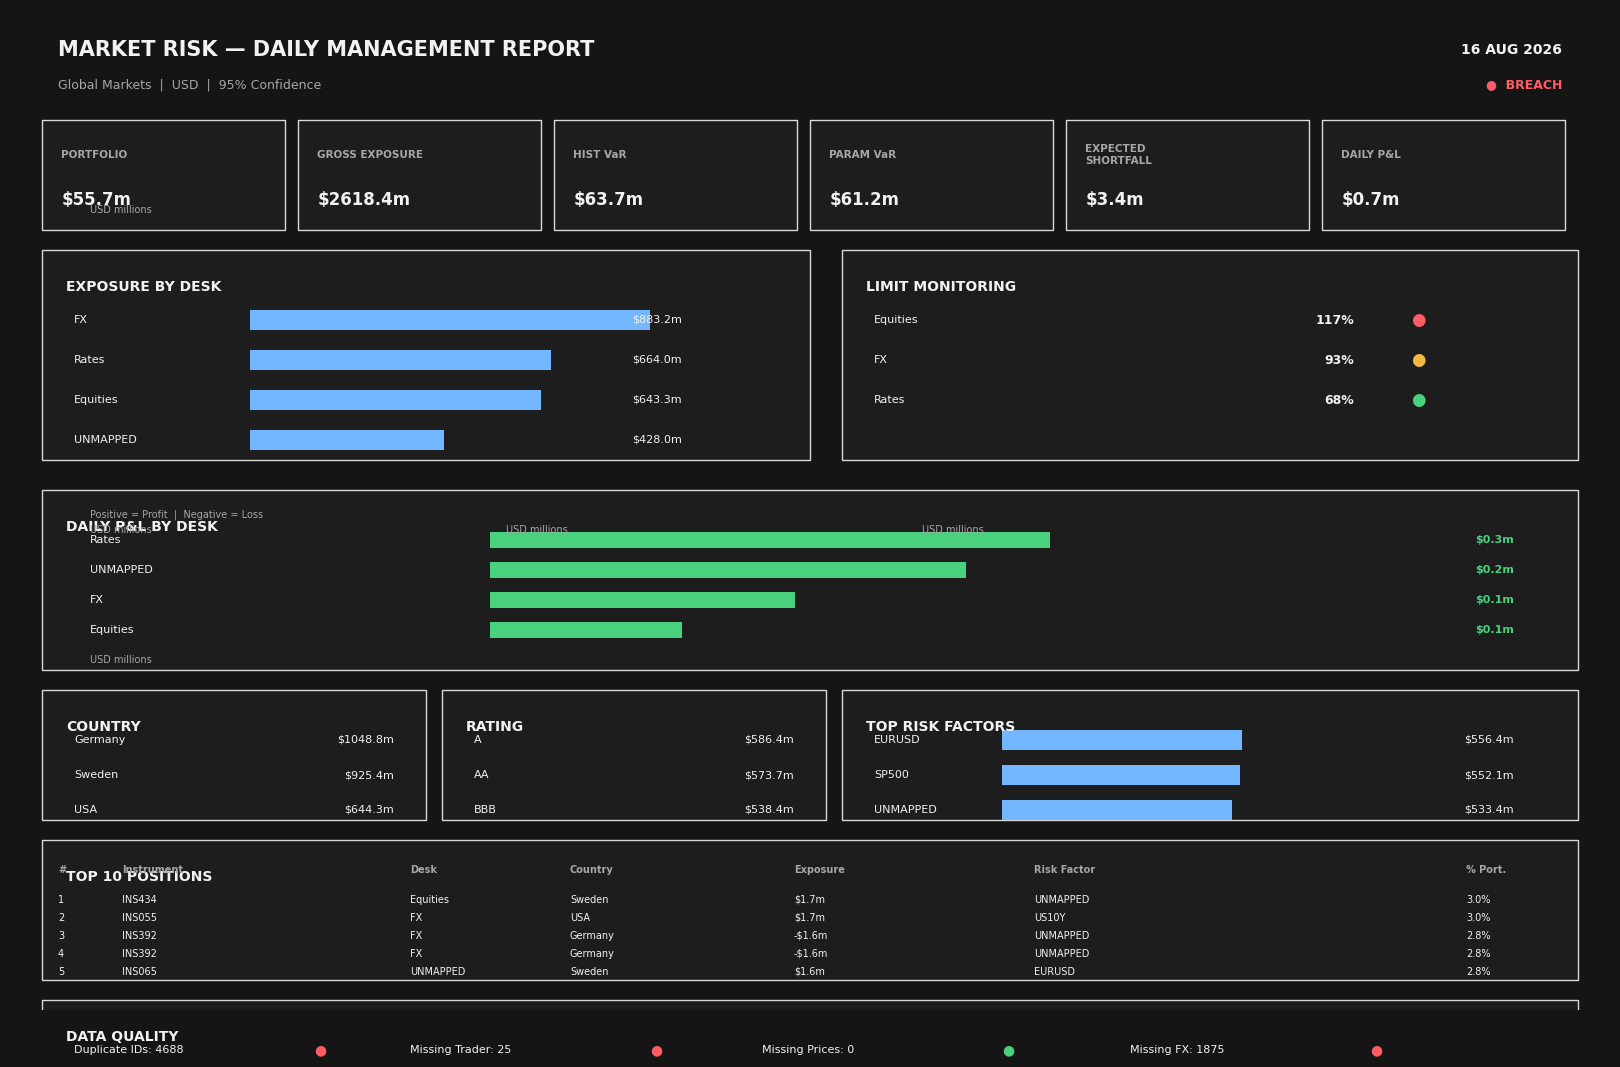

In [62]:
# ============================================================
# MARKET RISK — MANAGEMENT DASHBOARD
# ============================================================

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def money_m(x):
    """Format USD values in millions."""
    if pd.isna(x):
        return "N/A"
    
    sign = "-" if x < 0 else ""
    return f"{sign}${abs(x)/1e6:.1f}m"


def pct(x):
    """Format percentage."""
    if pd.isna(x):
        return "N/A"
    return f"{x:.0f}%"


# ------------------------------------------------------------
# Basic metrics
# ------------------------------------------------------------

portfolio_value = df_master["MarketValueUSD"].sum()

# Make risk numbers positive for management presentation
hist_var = abs(hvar_95)
param_var = abs(pvar_95)
expected_shortfall = abs(es_95)

latest_pnl = (
    df_master
    .sort_values("Date")
    .iloc[-1]["PnL"]
)

# ------------------------------------------------------------
# Exposure by desk
# ------------------------------------------------------------

desk_exposure = (
    df_master
    .groupby("Desk")["MarketValueUSD"]
    .apply(lambda x: x.abs().sum())
    .sort_values(ascending=False)
)


# ------------------------------------------------------------
# Country exposure
# ------------------------------------------------------------

country_exposure = (
    df_master
    .assign(
        Country=df_master["Country"].fillna("Unknown")
    )
    .groupby("Country")["MarketValueUSD"]
    .apply(lambda x: x.abs().sum())
    .sort_values(ascending=False)
    .head(3)
)


# ------------------------------------------------------------
# Rating exposure
# ------------------------------------------------------------

rating_exposure = (
    df_master
    .assign(
        Rating=df_master["Rating"].fillna("Not Rated")
    )
    .groupby("Rating")["MarketValueUSD"]
    .apply(lambda x: x.abs().sum())
    .sort_values(ascending=False)
    .head(3)
)


# ------------------------------------------------------------
# Risk factor exposure
# ------------------------------------------------------------

risk_factor_exposure = (
    df_master
    .assign(
        RiskFactor=df_master["RiskFactor"].fillna("Unmapped")
    )
    .groupby("RiskFactor")["MarketValueUSD"]
    .apply(lambda x: x.abs().sum())
    .sort_values(ascending=False)
    .head(3)
)


# ------------------------------------------------------------
# Top 10 positions
# ------------------------------------------------------------

top10 = (
    df_master
    .assign(
        GrossExposure=df_master["MarketValueUSD"].abs()
    )
    .sort_values(
        "GrossExposure",
        ascending=False
    )
    .head(10)
)


# ------------------------------------------------------------
# Limit monitoring
# ------------------------------------------------------------

limit_display = limit_check.copy()

# Make sure utilization is displayed as %
if limit_display["VaR_Utilization"].max() <= 2:
    limit_display["VaR_Utilization_Display"] = (
        limit_display["VaR_Utilization"] * 100
    )
else:
    limit_display["VaR_Utilization_Display"] = (
        limit_display["VaR_Utilization"]
    )

if limit_display["Position_Utilization"].max() <= 2:
    limit_display["Position_Utilization_Display"] = (
        limit_display["Position_Utilization"] * 100
    )
else:
    limit_display["Position_Utilization_Display"] = (
        limit_display["Position_Utilization"]
    )


# ------------------------------------------------------------
# Data quality
# ------------------------------------------------------------

dq = {
    "Duplicate IDs": df_master["TradeID"].duplicated().sum(),
    "Missing Trader": df_master["TraderID"].isna().sum(),
    "Missing Prices": df_master["Price"].isna().sum(),
    "Missing FX": df_master["USD_Rate"].isna().sum(),
    "Missing Counterparty": df_master["CounterpartyID"].isna().sum(),
    "Missing Rating": df_master["Rating"].isna().sum(),
    "Missing Risk Factor": df_master["RiskFactor"].isna().sum()
}

total_dq = sum(dq.values())

# Count desks with at least one limit breach
breaches = int(
    (
        (limit_display["VaR_Breach"] == "YES") |
        (limit_display["Position_Breach"] == "YES")
    ).sum()
)


# ============================================================
# FIGURE
# ============================================================

plt.close("all")

fig = plt.figure(
    figsize=(18, 11),
    facecolor="#151515"
)


# ------------------------------------------------------------
# Colors
# ------------------------------------------------------------

BG = "#151515"
PANEL = "#1D1D1D"
TEXT = "#F2F2F2"
MUTED = "#A7A7A7"
BORDER = "#D8D8D8"
GREEN = "#49D17D"
RED = "#FF5C67"
YELLOW = "#F5B942"
BLUE = "#72B7FF"


# ------------------------------------------------------------
# Main dashboard area
# ------------------------------------------------------------

ax = fig.add_axes([0, 0, 1, 1])

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

ax.axis("off")

ax.set_facecolor(BG)


# ============================================================
# FUNCTIONS FOR PANELS
# ============================================================

def panel(x, y, w, h, title):
    
    rect = Rectangle(
        (x, y),
        w,
        h,
        linewidth=1,
        edgecolor=BORDER,
        facecolor=PANEL
    )
    
    ax.add_patch(rect)
    
    ax.text(
        x + 1.5,
        y + h - 3,
        title,
        color=TEXT,
        fontsize=10,
        fontweight="bold",
        va="top"
    )


def text(x, y, value, size=9, color=TEXT, weight="normal",
         ha="left"):
    
    ax.text(
        x,
        y,
        str(value),
        color=color,
        fontsize=size,
        fontweight=weight,
        ha=ha,
        va="center"
    )


# ============================================================
# HEADER
# ============================================================

text(
    3,
    96,
    "MARKET RISK — DAILY MANAGEMENT REPORT",
    size=15,
    weight="bold"
)

text(
    3,
    92.5,
    "Global Markets  |  USD  |  95% Confidence",
    size=9,
    color=MUTED
)

text(
    97,
    96,
    datetime.now().strftime("%d %b %Y").upper(),
    size=10,
    weight="bold",
    ha="right"
)

# Status

status_color = RED if breaches > 0 else GREEN
status_text = "●  BREACH" if breaches > 0 else "●  WITHIN LIMITS"

text(
    97,
    92.5,
    status_text,
    size=9,
    color=status_color,
    weight="bold",
    ha="right"
)


# ============================================================
# KPI ROW
# ============================================================

kpi_y = 78
kpi_h = 11

gross_exposure = df_master["MarketValueUSD"].abs().sum()

kpis = [
    ("PORTFOLIO", money_m(portfolio_value)),
    ("GROSS EXPOSURE", money_m(gross_exposure)),
    ("HIST VaR", money_m(hist_var)),
    ("PARAM VaR", money_m(param_var)),
    ("EXPECTED\nSHORTFALL", money_m(expected_shortfall)),
    ("DAILY P&L", money_m(total_pnl))
]

kpi_width = 15.2

for i, (label, value) in enumerate(kpis):

    x = 2 + i * 16

    panel(
        x,
        kpi_y,
        kpi_width,
        kpi_h,
        ""
    )

    text(
        x + 1.2,
        kpi_y + 7.5,
        label,
        size=7.5,
        color=MUTED,
        weight="bold"
    )

    text(
        x + 1.2,
        kpi_y + 3,
        value,
        size=12,
        weight="bold"
    )


# ============================================================
# EXPOSURE BY DESK
# ============================================================

panel(
    2,
    55,
    48,
    21,
    "EXPOSURE BY DESK"
)
text(
    5,
    80,
    "USD millions",
    size=7,
    color=MUTED
)

desk_items = desk_exposure.head(4)

max_desk = desk_items.max()

for i, (desk, exposure) in enumerate(desk_items.items()):

    y = 69 - i * 4

    text(
        4,
        y,
        desk,
        size=8
    )

    bar_width = (
        exposure / max_desk * 25
        if max_desk != 0
        else 0
    )

    ax.add_patch(
        Rectangle(
            (15, y - 1),
            bar_width,
            2,
            facecolor=BLUE,
            edgecolor="none"
        )
    )

    text(
        42,
        y,
        money_m(exposure),
        size=8,
        ha="right"
    )


# ============================================================
# LIMIT MONITORING
# ============================================================

panel(
    52,
    55,
    46,
    21,
    "LIMIT MONITORING"
)

for i, (_, row) in enumerate(
    limit_display.iterrows()
):

    if i >= 4:
        break

    y = 69 - i * 4

    utilization = row["VaR_Utilization_Display"]

    if utilization >= 100:
        color = RED
    elif utilization >= 80:
        color = YELLOW
    else:
        color = GREEN

    text(
        54,
        y,
        row["Desk"],
        size=8
    )

    text(
        84,
        y,
        f"{utilization:.0f}%",
        size=9,
        weight="bold",
        ha="right"
    )

    text(
        88,
        y,
        "●",
        size=12,
        color=color,
        ha="center"
    )


# ============================================================
# DAILY P&L
# ============================================================

panel(
    2,
    34,
    96,
    18,
    "DAILY P&L BY DESK"
)


text(
    5,
    49.5,
    "Positive = Profit  |  Negative = Loss",
    size=7,
    color=MUTED
)

total_pnl = df_master["PnL"].sum()

pnl_items = (
    df_master
    .groupby("Desk")["PnL"]
    .sum()
    .sort_values(ascending=False)
)

max_pnl = pnl_items.abs().max()

for i, (desk, pnl) in enumerate(pnl_items.items()):

    y = 47 - i * 3

    text(
        5,
        y,
        desk,
        size=8
    )

    if max_pnl != 0:
        bar_width = abs(pnl) / max_pnl * 35
    else:
        bar_width = 0

    if pnl >= 0:
        ax.add_patch(
            Rectangle(
                (30, y - 0.8),
                bar_width,
                1.6,
                facecolor=GREEN,
                edgecolor="none"
            )
        )
    else:
        ax.add_patch(
            Rectangle(
                (30 - bar_width, y - 0.8),
                bar_width,
                1.6,
                facecolor=RED,
                edgecolor="none"
            )
        )

    text(
        94,
        y,
        money_m(pnl),
        size=8,
        ha="right",
        color=GREEN if pnl >= 0 else RED,
        weight="bold"
    )

# ============================================================
# COUNTRY
# ============================================================

panel(
    2,
    19,
    24,
    13,
    "COUNTRY"
)

text(
    5,
    48,
    "USD millions",
    size=7,
    color=MUTED
)


for i, (country, exposure) in enumerate(
    country_exposure.items()
):

    y = 27 - i * 3.5

    text(
        4,
        y,
        country,
        size=8
    )

    text(
        24,
        y,
        money_m(exposure),
        size=8,
        ha="right"
    )


# ============================================================
# RATING
# ============================================================

panel(
    27,
    19,
    24,
    13,
    "RATING"
)

text(
    31,
    48,
    "USD millions",
    size=7,
    color=MUTED
)

for i, (rating, exposure) in enumerate(
    rating_exposure.items()
):

    y = 27 - i * 3.5

    text(
        29,
        y,
        rating,
        size=8
    )

    text(
        49,
        y,
        money_m(exposure),
        size=8,
        ha="right"
    )


# ============================================================
# RISK FACTORS
# ============================================================

panel(
    52,
    19,
    46,
    13,
    "TOP RISK FACTORS"
)

text(
    57,
    48,
    "USD millions",
    size=7,
    color=MUTED
)

for i, (factor, exposure) in enumerate(
    risk_factor_exposure.items()
):

    y = 27 - i * 3.5

    text(
        54,
        y,
        factor,
        size=8
    )

    bar_width = min(
        exposure / risk_factor_exposure.max() * 15,
        15
    )

    ax.add_patch(
        Rectangle(
            (62, y - 1),
            bar_width,
            2,
            facecolor=BLUE,
            edgecolor="none"
        )
    )

    text(
        94,
        y,
        money_m(exposure),
        size=8,
        ha="right"
    )


# ============================================================
# TOP 10 POSITIONS
# ============================================================

panel(
    2,
    3,
    96,
    14,
    "TOP 10 POSITIONS"
)

text(
    5,
    35,
    "USD millions",
    size=7,
    color=MUTED
)

# Header

headers = [
    ("#", 3),
    ("Instrument", 7),
    ("Desk", 25),
    ("Country", 35),
    ("Exposure", 49),
    ("Risk Factor", 64),
    ("% Port.", 91)
]

for label, x in headers:

    text(
        x,
        14,
        label,
        size=7,
        color=MUTED,
        weight="bold"
    )


# Rows

for i, (_, row) in enumerate(
    top10.head(5).iterrows()
):

    y = 11 - i * 1.8

    risk_factor = (
        row["RiskFactor"]
        if pd.notna(row["RiskFactor"])
        else "N/A"
    )

    portfolio_pct = (
        abs(row["MarketValueUSD"])
        / abs(portfolio_value)
        * 100
        if portfolio_value != 0
        else 0
    )

    text(3, y, i + 1, size=7)

    text(
        7,
        y,
        row["InstrumentID"],
        size=7
    )

    text(
        25,
        y,
        row["Desk"],
        size=7
    )

    text(
        35,
        y,
        row["Country"],
        size=7
    )

    text(
        49,
        y,
        money_m(row["MarketValueUSD"]),
        size=7
    )

    text(
        64,
        y,
        risk_factor,
        size=7
    )

    text(
        91,
        y,
        f"{portfolio_pct:.1f}%",
        size=7
    )


# ============================================================
# DATA QUALITY
# ============================================================

panel(
    2,
    -8,
    96,
    9,
    "DATA QUALITY"
)

x_positions = [
    4,
    25,
    47,
    70
]

items = list(dq.items())

for i, (metric, count) in enumerate(items[:4]):

    x = x_positions[i]

    text(
        x,
        -4,
        f"{metric}: {count}",
        size=8
    )

    if count == 0:
        color = GREEN
    else:
        color = RED

    text(
        x + 15,
        -4,
        "●",
        size=10,
        color=color
    )


# ============================================================
# FINAL DISPLAY
# ============================================================

# Save as a pdf
fig.set_size_inches(16, 10)

fig.savefig(
    "Market_Risk_Management_Dashboard.pdf",
    format="pdf",
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()